<a href="https://colab.research.google.com/github/JacquelinePantoja/repo_for_DS4PHinP/blob/main/Midterm_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

inport data, try to resize the data to make it manageable (limit to one month)

In [2]:
import pandas as pd
prk = pd.read_csv('/content/Finance_Parking_Fines_425930082550913200.csv')
#prk.head()
#prk.columns

keep only necessary columns

In [4]:
#prk.dropna()
#prk.columns
prk_subset = prk[['Citation', 'Tag', 'ExpMM', 'ExpYY', 'State', 'Make', 'Address', 'Description', 'ViolFine', 'ViolDate', 'Balance', 'Location']]
prk_subset['ViolTime'] = prk_subset['ViolDate']
prk_subset.head(6)

/tmp/ipykernel_154/995130453.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prk_subset['ViolTime'] = prk_subset['ViolDate']


,Citation,Tag,ExpMM,ExpYY,State,Make,Address,Description,ViolFine,ViolDate,Balance,Location,ViolTime
0,91,03W671,08,10,MD,FORD,O/S 1900 E EAGER ST,No Stop/Park Street Cleaning,52,12/9/2011 11:55:00 AM,552,NaN,12/9/2011 11:55:00 AM
1,166,T294093T,12,11,MD,JEEP,2300 E MONUMENT,No Stopping/Standing Not Tow-Away Zone,32,12/9/2011 12:39:00 PM,32,NaN,12/9/2011 12:39:00 PM
2,299,19TLR318,02,13,ME,NaN,900 LOW ST,All Other Stopping or Parking Violations,32,12/9/2011 11:55:00 AM,32,NaN,12/9/2011 11:55:00 AM
3,315,14TLR551,11,14,ME,NaN,1000 LOW ST,All Other Stopping or Parking Violations,32,12/9/2011 12:02:00 PM,32,NaN,12/9/2011 12:02:00 PM
4,562,9AE2340,03,13,MD,SUZU,LAFAYETTE MARKET LOT,All Other Parking Meter Violations,32,12/12/2011 10:47:00 AM,0,LAFAYETTE MARKET LOT Baltimore MD,12/12/2011 10:47:00 AM
5,653,SG23690,12,99,MD,CHEV,2000 W FAYETTE ST,Obstruct/Impeding Movement of Pedestrian,77,12/12/2011 12:17:00 PM,827,"(39.28960468, -76.64890053)",12/12/2011 12:17:00 PM


Need a column to differentiate day and nigh times #code from google ai

In [5]:
import numpy as np
prk_subset.loc[:, 'TimeOfDay'] = np.where(prk_subset['ViolDate'].str.contains('AM'), 'day', 'night')

/tmp/ipykernel_154/3816199422.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prk_subset.loc[:, 'TimeOfDay'] = np.where(prk_subset['ViolDate'].str.contains('AM'), 'day', 'night')


turn mdy in ViolDate column from object type to period type (yyy-mm)

In [ ]:
#prk_subset["ViolTime"].str.split(n=2).str[1]

In [6]:
#prk_subset["ViolDate"].dtype
prk_subset.loc[:, "ViolTime"] = prk_subset["ViolTime"].str.split(n=2).str[1]
prk_subset.loc[:, "ViolDate"] = prk_subset["ViolDate"].str.split(' ', n=1).str[0]
#prk_subset["Date"].dtype
#prk_subset["Date"].head(20)
prk_subset.loc[:, "Date"] = pd.to_datetime(prk_subset["ViolDate"]).dt.to_period('M')
#prk_subset["Date"].head(20)
prk_subset.head(20)

/tmp/ipykernel_154/1111696891.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prk_subset.loc[:, "Date"] = pd.to_datetime(prk_subset["ViolDate"]).dt.to_period('M')


,Citation,Tag,ExpMM,ExpYY,State,Make,Address,Description,ViolFine,ViolDate,Balance,Location,ViolTime,TimeOfDay,Date
0,91,03W671,08,10,MD,FORD,O/S 1900 E EAGER ST,No Stop/Park Street Cleaning,52,12/9/2011,552,NaN,11:55:00,day,2011-12
1,166,T294093T,12,11,MD,JEEP,2300 E MONUMENT,No Stopping/Standing Not Tow-Away Zone,32,12/9/2011,32,NaN,12:39:00,night,2011-12
2,299,19TLR318,02,13,ME,NaN,900 LOW ST,All Other Stopping or Parking Violations,32,12/9/2011,32,NaN,11:55:00,day,2011-12
3,315,14TLR551,11,14,ME,NaN,1000 LOW ST,All Other Stopping or Parking Violations,32,12/9/2011,32,NaN,12:02:00,night,2011-12
4,562,9AE2340,03,13,MD,SUZU,LAFAYETTE MARKET LOT,All Other Parking Meter Violations,32,12/12/2011,0,LAFAYETTE MARKET LOT Baltimore MD,10:47:00,day,2011-12
5,653,SG23690,12,99,MD,CHEV,2000 W FAYETTE ST,Obstruct/Impeding Movement of Pedestrian,77,12/12/2011,827,"(39.28960468, -76.64890053)",12:17:00,night,2011-12
6,703,7AB5707,10,12,MD,NISS,2600 LAURETTA AVE,No Stop/Park Street Cleaning,52,12/29/2011,552,"(39.29407531, -76.65950967)",8:18:00,day,2011-12
7,711,3AG8711,04,12,MD,ACURA,2600 LAURETTA AVE,No Stop/Park Street Cleaning,52,12/29/2011,0,2600 LAURETTA AVE Baltimore MD,8:18:00,day,2011-12
8,729,6AD5111,01,13,MD,NISS,2800 HARLEM AVE,No Stop/Park Street Cleaning,52,12/29/2011,0,2800 HARLEM AVE Baltimore MD,8:28:00,day,2011-12
9,1016,93475CD,03,12,MD,ACURA,700 PENNSYLVANIA AVE,No Stop/Park Street Cleaning,52,12/12/2011,52,700 PENNSYLVANIA AVE Baltimore MD,7:12:00,day,2011-12


In [ ]:
#prk["Date"].mode() #2012-11 most common period
date_df = prk_subset[prk_subset['Date'] == '2014-04']
#date_df = date_df[date_df['State'] == 'MD']
date_df = date_df[date_df['Balance'] > 0]
date_df.loc[:, "Day"] = pd.to_datetime(date_df["ViolDate"]).dt.day
date_df.loc[:, "Time"] = pd.to_datetime(date_df["ViolTime"]).dt.time
#date_df.shape #(566, 13)
#date_df.dropna().shape
date_df.head(20)

/tmp/ipykernel_34596/148955512.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date_df.loc[:, "Time"] = pd.to_datetime(date_df["ViolTime"]).dt.time


,Citation,Tag,ExpMM,ExpYY,State,Make,Address,Description,ViolFine,ViolDate,Balance,Location,ViolTime,TimeOfDay,Date,Day,Time
2211,105817,6BF8566,03,16,MD,CHRY,E/S 1600 DIVISION,Passenger Loading Zone,32,4/8/2014,357,NaN,12:30:00,night,2014-04,8,12:30:00
2379,115501,3AZ1934,12,15,MD,BMW,1300 W LANVALE ST,All Other Stopping or Parking Violations,32,4/11/2014,332,NaN,2:40:00,day,2014-04,11,02:40:00
2455,118950,9AZ2214,03,14,MD,CHRY,1625 ABBTON ST,Exceeding 48 Hours,32,4/23/2014,357,NaN,3:30:00,night,2014-04,23,03:30:00
2482,120873,056566T,05,14,MD,DODG,527 PARKSLEY ST,Less Than 15 feet from Fire Hydrant,77,4/17/2014,77,NaN,4:45:00,day,2014-04,17,04:45:00
3363,198853,45825Z,08,13,MD,CHEV,608 N BELNORD AV,Expired Tags,32,4/22/2014,332,NaN,11:15:00,day,2014-04,22,11:15:00
3529,207449,T772256T,07,13,MD,HYUN,E/S 500 N LOUDON AVE,Expired Tags,32,4/26/2014,32,NaN,11:45:00,day,2014-04,26,11:45:00
3539,207894,2AH3578,05,15,MD,CHEV,2400 SHIRLEY,Exceeding 48 Hours,32,4/9/2014,357,NaN,4:28:00,day,2014-04,9,04:28:00
4894,347260,40962MB,08,12,MD,DODG,O/S 2000 N FAYETTE ST,Obstruct/Impeding Flow of Traffic,102,4/8/2014,102,NaN,1:25:00,night,2014-04,8,01:25:00
4905,349894,9AW2963,02,15,MD,FORD,1600 W BALTIMORE ST,No Stopping/Standing Not Tow-Away Zone,32,4/27/2014,357,"(39.28857443, -76.64254410)",12:15:00,night,2014-04,27,12:15:00
4990,359836,3AS7691,04,14,MD,NISS,O/S 200 N PACA ST,All Other Parking Meter Violations,32,4/5/2014,357,NaN,11:00:00,day,2014-04,5,11:00:00


Violations for the month of november in 2012 with a fine > $0:

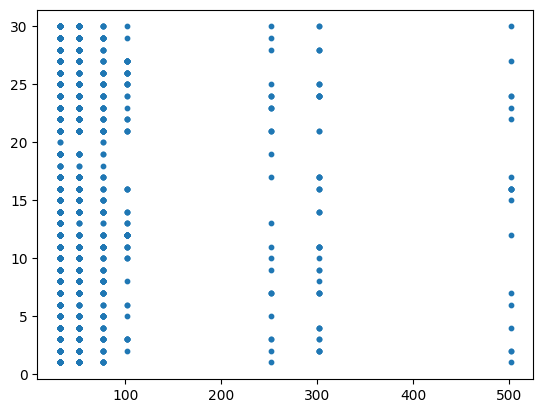

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(date_df['ViolFine'] , date_df['Day'] , s=10)
plt.show()

In [ ]:
## code from google ai
date_df.loc[:, "balance_group"] = pd.qcut(date_df["Balance"], q=3, labels=["low", "middle", "high"])
#date_df["Balance"].nunique() #42 unique amounts to be fined
#date_df["Balance"].min()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


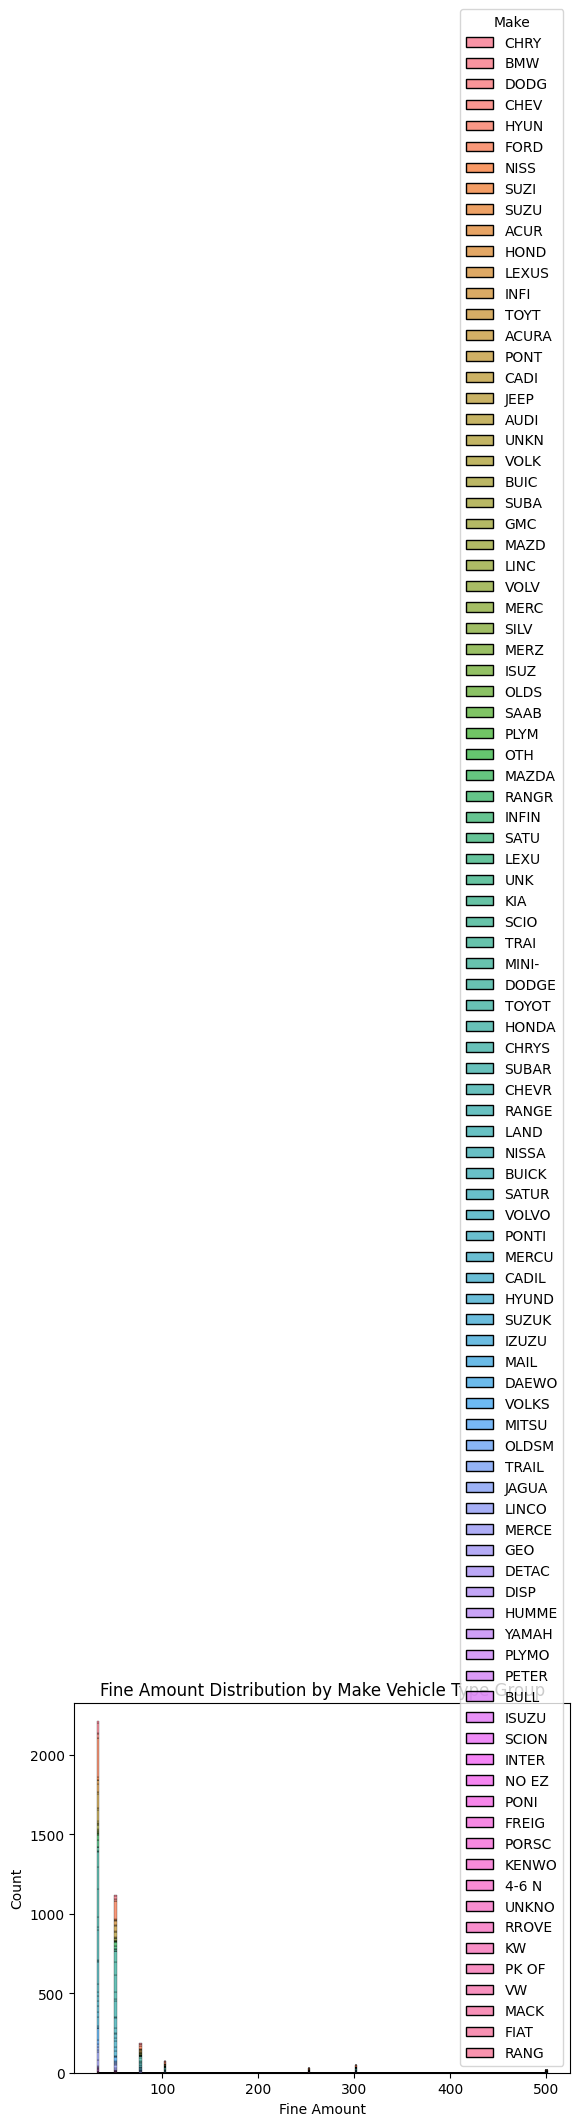

In [ ]:
#code from google ai
import seaborn as sns

# multiple='stack' prevents overlapping bars; use 'dodge' to put them side-by-side
sns.histplot(data=date_df, x="ViolFine", hue="Make", multiple="stack")

plt.title("Fine Amount Distribution by Make Vehicle Type Group")
plt.xlabel("Fine Amount")
plt.ylabel("Count")
plt.show()


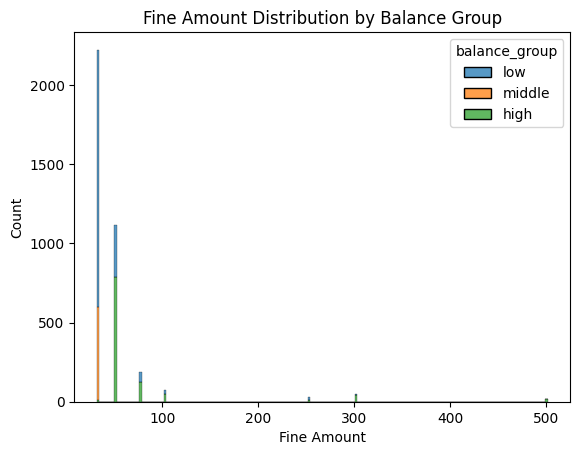

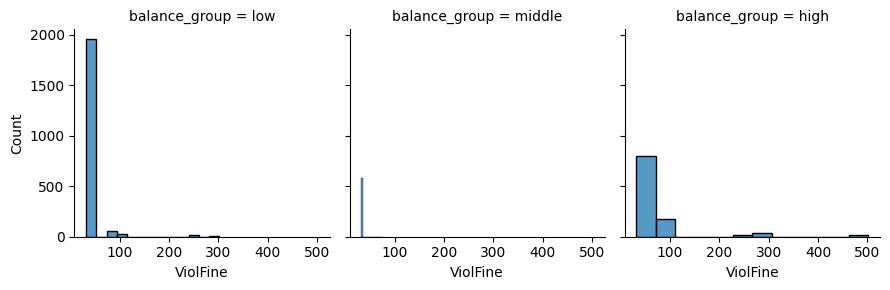

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=date_df, x="ViolFine", hue="balance_group", multiple="stack")

plt.title("Fine Amount Distribution by Balance Group")
plt.xlabel("Fine Amount")
plt.ylabel("Count")
plt.show()

g = sns.FacetGrid(date_df, col="balance_group")
g.map(sns.histplot, "ViolFine")


Check what the balance is for middle balance individuals

 -> in 2014-04, balance is $32 for all

In [ ]:
date_df_middle = date_df[date_df["balance_group"] == "middle"]

date_df_middle["ViolFine"].max()
date_df_middle["ViolFine"].unique()


array([32, 77, 52])

times range from 11:59 PM to 1:00 AM

In [ ]:
#date_df.sort_values(["TimeOfDay", "Time"], ascending=False)
#date_df.sort_values(["TimeOfDay", "Time"])

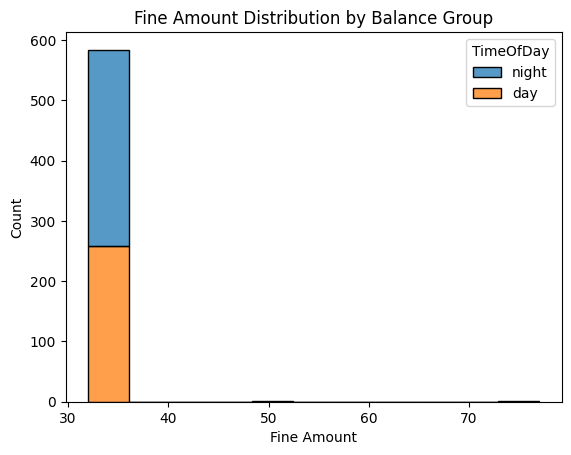

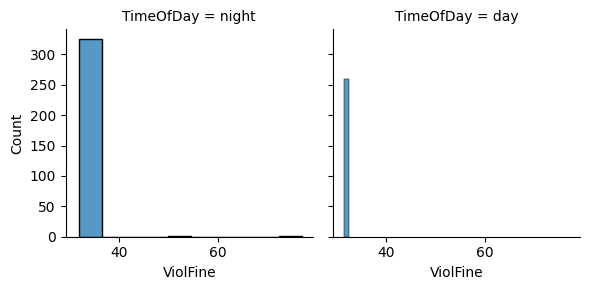

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=date_df_middle, x="ViolFine", hue="TimeOfDay", multiple="stack")

plt.title("Fine Amount Distribution by Balance Group")
plt.xlabel("Fine Amount")
plt.ylabel("Count")
plt.show()

g = sns.FacetGrid(date_df_middle, col="TimeOfDay")
g.map(sns.histplot, "ViolFine")

In [ ]:
date_df_middle['Description'].value_counts()
#date_df_middle['Description'].unique()

array(['Passenger Loading Zone', 'Exceeding 48 Hours',
       'No Stopping/Standing Not Tow-Away Zone',
       'All Other Parking Meter Violations', 'Expired Tags',
       'All Other Stopping or Parking Violations',
       'Blocking Garage or Driveway',
       'No Parking/Standing In Transit Stop',
       'Residential Parking Permit Only'], dtype=object)

In [ ]:
# Group by Description and calculate both size (counts) and mean (average)
#Code by Google AI
summary = date_df_middle.groupby('Description')['ViolFine'].agg(['count', 'mean'])
summary = summary.sort_values(by='count', ascending=False)
summary

,count,mean
Description,,
All Other Parking Meter Violations,256,32.0
Expired Tags,150,32.0
No Stopping/Standing Not Tow-Away Zone,112,32.0
All Other Stopping or Parking Violations,43,32.0
Exceeding 48 Hours,12,32.0
Passenger Loading Zone,9,32.0
Blocking Garage or Driveway,2,32.0
No Parking/Standing In Transit Stop,1,77.0
Residential Parking Permit Only,1,52.0


Exclude the two exceptions to fine amount (77 & 52).

In [ ]:
#date_df_middletest = date_df_middle[date_df_middle["ViolFine"] != 32]
#date_df_middletest
date_df_middle = date_df_middle[date_df_middle["ViolFine"] == 32]
date_df_middle.shape

(584, 18)

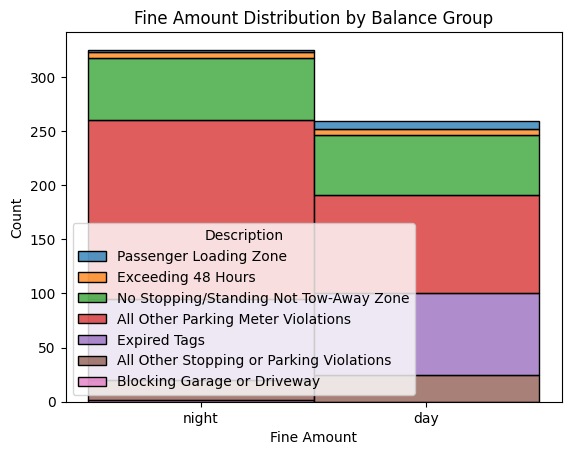

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=date_df_middle, x="TimeOfDay", hue="Description", multiple="stack")

plt.title("Description Distribution by Time of day")
plt.xlabel("Description")
plt.ylabel("Count")
plt.show()

#g = sns.FacetGrid(date_df_middle, col="Description")
#g.map(sns.histplot, "ViolFine")

In [ ]:
summary = date_df_middle.groupby(['TimeOfDay','Description']).agg('count')
summary.iloc[:, 0]

TimeOfDay  Description                             
day        All Other Parking Meter Violations           91
           All Other Stopping or Parking Violations     25
           Exceeding 48 Hours                            6
           Expired Tags                                 75
           No Stopping/Standing Not Tow-Away Zone       55
           Passenger Loading Zone                        7
night      All Other Parking Meter Violations          165
           All Other Stopping or Parking Violations     18
           Blocking Garage or Driveway                   2
           Exceeding 48 Hours                            6
           Expired Tags                                 75
           No Stopping/Standing Not Tow-Away Zone       57
           Passenger Loading Zone                        2
Name: Citation, dtype: int64

In [ ]:
date_df_middle_night = date_df_middle[date_df_middle["TimeOfDay"] == "night"]

date_df_middle_day = date_df_middle[date_df_middle["TimeOfDay"] == "day"]

In [ ]:
date_df_middle_night['Time'].dtype
#code from google AI

date_df_middle_night.loc[:, 'Hour'] = pd.to_datetime(date_df_middle_night['Time'], format='%H:%M:%S').dt.hour
date_df_middle_day.loc[:, 'Hour'] = pd.to_datetime(date_df_middle_day['Time'], format='%H:%M:%S').dt.hour
#date_df_middle_night['Time'] = date_df_middle_night['Time'].str.split(':', n=1).str[0].astype(int)
#date_df_middle_day['Time'] = date_df_middle_day['Time'].dt.hour

date_df_middle_night.loc[:, 'Time'] = date_df_middle_night['Time'].replace(12, 0)
date_df_middle_day.loc[:, 'Time'] = date_df_middle_day['Time'].replace(12, 0)


<Axes: xlabel='Hour', ylabel='Count'>

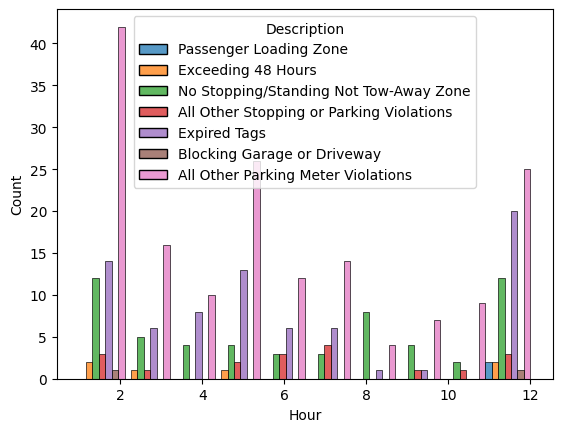

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=date_df_middle_night, x="Hour", hue="Description", multiple="dodge")

In [ ]:
#date_df_middle_day['Hour'].max()

12

<Axes: xlabel='Hour', ylabel='Count'>

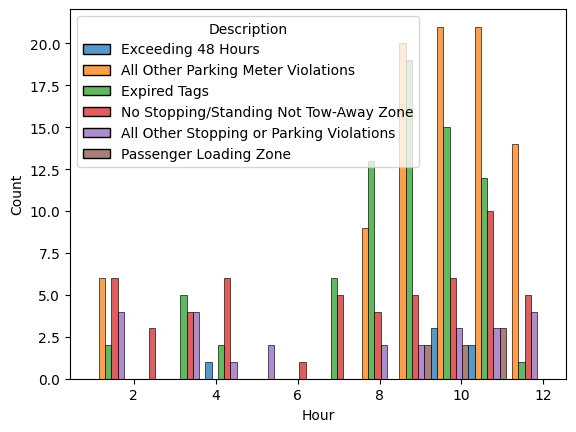

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data=date_df_middle_day, x="Hour", hue="Description", multiple="dodge")

Now lets look a little deeper at expired tags, and if the tags expiration were the same across all make types

In [ ]:
date_df_middle_day.head(2)
#date_df_middle_day['ExpYY'].dtype

,Citation,Tag,ExpMM,ExpYY,State,Make,Address,Description,ViolFine,ViolDate,Balance,Location,ViolTime,TimeOfDay,Date,Day,Time,balance_group,Hour,Expired_Tags
3539,207894,2AH3578,5,15,MD,CHEV,2400 SHIRLEY,Exceeding 48 Hours,32,4/9/2014,357,NaN,4:28:00,day,2014-04,9,04:28:00,middle,4,yes
4990,359836,3AS7691,4,14,MD,NISS,O/S 200 N PACA ST,All Other Parking Meter Violations,32,4/5/2014,357,NaN,11:00:00,day,2014-04,5,11:00:00,middle,11,yes


In [ ]:
#date_df_middle_day['Time'] = date_df_middle_day['Time'].str.split(':', n=1).str[0].astype(int)

In [ ]:
#code from google ai
date_df_middle_day.loc[:, ['ExpMM', 'ExpYY']] = date_df_middle_day[['ExpMM', 'ExpYY']].astype(int)
date_df_middle_night.loc[:, ['ExpMM', 'ExpYY']] = date_df_middle_night[['ExpMM', 'ExpYY']].astype(int)

In [ ]:
date_df_middle_day['ExpYY'].dtype
date_df_middle_night['ExpYY'].dtype

dtype('int64')

In [ ]:
import numpy as np

# Condition 1: Year > 2014
# Condition 2: Year == 2014 AND Month > 4
no_condition = (date_df_middle_night['ExpYY'] > 14) | ((date_df_middle_night['ExpYY'] == 14) & (date_df_middle_night['ExpMM'] > 4))

date_df_middle_night.loc[:, 'Expired_Tags'] = np.where(no_condition, 'no', 'yes')


In [ ]:
import numpy as np

# Condition 1: Year > 2014
# Condition 2: Year == 2014 AND Month > 4
no_condition = (date_df_middle_day['ExpYY'] > 14) | ((date_df_middle_day['ExpYY'] == 14) & (date_df_middle_day['ExpMM'] > 4))

date_df_middle_day.loc[:, 'Expired_Tags'] = np.where(no_condition, 'no', 'yes')

lets see what comes up when we sort descriptions by expired tags status

In [ ]:
date_df_middle_day

,Citation,Tag,ExpMM,ExpYY,State,Make,Address,Description,ViolFine,ViolDate,Balance,Location,ViolTime,TimeOfDay,Date,Day,Time,balance_group,Hour,Expired_Tags
3539,207894,2AH3578,5,15,MD,CHEV,2400 SHIRLEY,Exceeding 48 Hours,32,4/9/2014,357,NaN,4:28:00,day,2014-04,9,04:28:00,middle,4,no
4990,359836,3AS7691,4,14,MD,NISS,O/S 200 N PACA ST,All Other Parking Meter Violations,32,4/5/2014,357,NaN,11:00:00,day,2014-04,5,11:00:00,middle,11,yes
7368,516849,7AL6719,1,14,MD,SUZI,O/S 3300 BLK CARDNAS,Expired Tags,32,4/8/2014,357,NaN,11:55:00,day,2014-04,8,11:55:00,middle,11,yes
18834,1236702,3AY2364,12,14,MD,NISS,O/S 205 W READ ST,No Stopping/Standing Not Tow-Away Zone,32,4/21/2014,357,NaN,2:00:00,day,2014-04,21,02:00:00,middle,2,no
18981,1247964,5AK6829,9,15,MD,TOYT,300 W PRESTON ST,No Stopping/Standing Not Tow-Away Zone,32,4/2/2014,357,"(39.30222867, -76.62307016)",10:39:00,day,2014-04,2,10:39:00,middle,10,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
722904,24059792,2BF5255,3,14,MD,CHEVR,1900 LAURETTA AVE,Expired Tags,32,4/29/2014,357,"(39.29463871, -76.64771809)",9:03:00,day,2014-04,29,09:03:00,middle,9,yes
4331389,79001939,6BF8465,3,14,MD,FORD,E/S 1003 WHEELER,Expired Tags,32,4/2/2014,357,NaN,7:00:00,day,2014-04,2,07:00:00,middle,7,yes
4331509,79020608,3BK1642,3,14,MD,BMW,E/S 732 N KENWOOD,Expired Tags,32,4/12/2014,357,NaN,8:15:00,day,2014-04,12,08:15:00,middle,8,yes
4331511,79020640,54535M6,4,16,MD,FORD,O/S 900 LAKEWOOD,Expired Tags,32,4/12/2014,357,NaN,8:30:00,day,2014-04,12,08:30:00,middle,8,no


In [ ]:
summary = date_df_middle_day.groupby(['Expired_Tags','Description']).agg('count')
summary.iloc[:, 0]

Expired_Tags  Description                             
no            All Other Parking Meter Violations          86
              All Other Stopping or Parking Violations    23
              Exceeding 48 Hours                           5
              Expired Tags                                35
              No Stopping/Standing Not Tow-Away Zone      51
              Passenger Loading Zone                       7
yes           All Other Parking Meter Violations           5
              All Other Stopping or Parking Violations     2
              Exceeding 48 Hours                           1
              Expired Tags                                40
              No Stopping/Standing Not Tow-Away Zone       4
Name: Citation, dtype: int64

In [ ]:
summary = date_df_middle_night.groupby(['Expired_Tags','Description']).agg('count')
summary.iloc[:, 0]

Expired_Tags  Description                             
no            All Other Parking Meter Violations          155
              All Other Stopping or Parking Violations     17
              Blocking Garage or Driveway                   2
              Exceeding 48 Hours                            4
              Expired Tags                                 27
              No Stopping/Standing Not Tow-Away Zone       53
              Passenger Loading Zone                        2
yes           All Other Parking Meter Violations           10
              All Other Stopping or Parking Violations      1
              Exceeding 48 Hours                            2
              Expired Tags                                 48
              No Stopping/Standing Not Tow-Away Zone        4
Name: Citation, dtype: int64

In [ ]:
date_df_middle_night_exp = date_df_middle_night[date_df_middle_night["Expired_Tags"] == "no"]
date_df_middle_night_exp = date_df_middle_night_exp[date_df_middle_night_exp["Description"] == "Expired Tags"]

date_df_middle_day_exp = date_df_middle_day[date_df_middle_day["Expired_Tags"] == "no"]
date_df_middle_day_exp = date_df_middle_day_exp[date_df_middle_day_exp["Description"] == "Expired Tags"]

lets look into these 62 cases where the tags were not expired yet the traffic violation was issued for expired tags

In [ ]:
date_df_middle_night_exp.shape
date_df_middle_day_exp.shape

(35, 20)

<Axes: xlabel='Hour', ylabel='Count'>

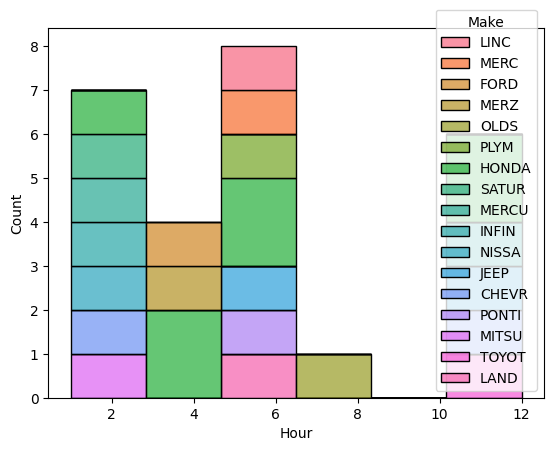

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data=date_df_middle_night_exp, x="Hour", hue="Make", multiple="stack")

In [ ]:
summary = date_df_middle_night_exp.groupby('Make').agg('count')
summary.iloc[:, 0].sort_values(ascending=False)

,Citation
Make,
HONDA,7
CHEVR,2
INFIN,2
JEEP,2
FORD,1
LAND,1
LINC,1
MERC,1
MERCU,1


<Axes: xlabel='Hour', ylabel='Count'>

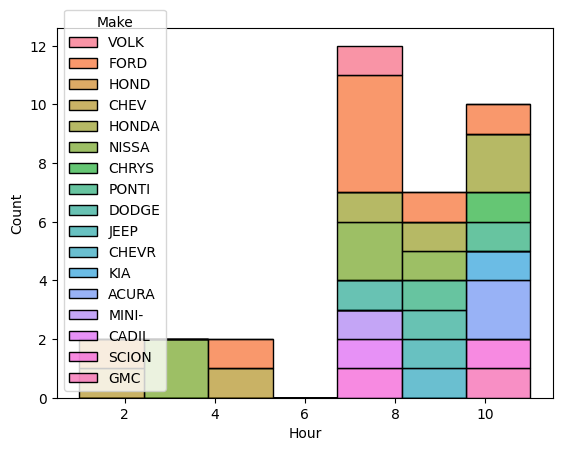

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data=date_df_middle_day_exp, x="Hour", hue="Make", multiple="stack")

In [ ]:
summary = date_df_middle_day_exp.groupby('Make').agg('count')
summary.iloc[:, 0].sort_values(ascending=False)

,Citation
Make,
FORD,7
NISSA,5
HONDA,4
ACURA,2
CHEV,2
SCION,2
PONTI,2
DODGE,2
CADIL,1


any overall trends in non-expired tags?

In [8]:
park = prk_subset
park.loc[:, "Date"] = pd.to_datetime(prk_subset["ViolDate"]).dt.year
park.loc[:, "Month"] = pd.to_datetime(park["ViolDate"]).dt.month
park.loc[:, "Year"] = (park["Date"] - 2000) #.astype('Int64')

#date_df.loc[:, "Year"] = pd.to_datetime(date_df["ViolDate"]).
#date_df.loc[:, "Year"] = date_df["Year"].dt.year
#prk_subset.loc[:, "ViolTime"] = prk_subset["ViolTime"].str.split(n=2).str[1]
#prk_subset.loc[:, "ViolDate"] = prk_subset["ViolDate"].str.split(' ', n=1).str[0]
#park['ViolDate']

In [ ]:
#park['Date'].dtype

In [9]:
park.loc[:, ['ExpMM', 'ExpYY']] = park[['ExpMM', 'ExpYY']].apply(pd.to_numeric, errors='coerce').astype('Int64')
#fixed errors with Gemini AI

In [11]:
import numpy as np

# Condition 1: Year > 2014
# Condition 2: Year == 2014 AND Month > 4
no_condition = (park['ExpYY'] > park['Year']) | ((park['ExpYY'] == park['Year']) & (park['ExpMM'] > park['Month']))

park.loc[:, 'Expired_Tags'] = np.where(no_condition, 'no', 'yes')

In [ ]:
#park['Description'].value_counts()
#date_df_middle_night[date_df_middle_night["Expired_Tags"] == "no"]

In [27]:
park.shape

(188008, 18)

In [22]:
park_exp = park[park['Expired_Tags'] == 'yes']
park_not_exp = park[park['Expired_Tags'] == 'no']

In [37]:
#Code from Google AI
summary = park_exp.groupby('Description')['Description'].agg(['count'])
summary['percentage'] = (summary['count'] / summary['count'].sum()) * 100
summary = summary.sort_values(by='count', ascending=False)
summary.head()

,count,percentage
Description,,
Expired Tags,23449,55.964200
All Other Parking Meter Violations,3165,7.553699
No Stopping/Standing Tow Away Zone,2650,6.324582
No Stopping/Standing Not Tow-Away Zone,2637,6.293556
No Stop/Park Street Cleaning,1752,4.181384


In [39]:
park_exp.shape
park_not_exp.shape

(146108, 18)

In [38]:
summary = park_not_exp.groupby('Description')['Description'].agg(['count'])
summary['percentages'] = (summary['count'] / summary['count'].sum()) * 100
summary = summary.sort_values(by='count', ascending=False)
summary.head(8)

,count,percentages
Description,,
All Other Parking Meter Violations,35556,24.335423
No Stopping/Standing Not Tow-Away Zone,20139,13.783639
No Stopping/Standing Tow Away Zone,19935,13.644017
No Stop/Park Street Cleaning,13115,8.976237
All Other Stopping or Parking Violations,9468,6.480138
Residential Parking Permit Only,7328,5.015468
Expired Tags,6927,4.741013
Less Than 15 feet from Fire Hydrant,5071,3.470720
